In [3]:
# Benchmark Analysis: 2-Rank and 17-Rank BiCGStab Solvers
# 
# This notebook reproduces all benchmark analysis results for HetHypPar.
# Two benchmark configurations are analyzed:
#   - 2-rank (1 CPU + 1 GPU): data/results/benchmark_summary.tsv
#   - 17-rank (16 CPU + 1 GPU): data/logs/benchmark_results_*.tsv
#
# Both runs use 1000 BiCGStab iterations across 200+ sparse matrices.

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

def find_project_root(current_dir, marker=".git"):
    """Traverse upwards to find the project root containing the marker."""
    for path in [current_dir] + list(current_dir.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Project root with '{marker}' not found.")

# Let Python find the root dynamically
# Change ".git" to whatever uniquely identifies your project's top folder
PROJECT_ROOT = find_project_root(Path.cwd(), marker=".git")

RESULTS_2RANK = PROJECT_ROOT / "data" / "results" / "benchmark_summary.tsv"
LOGS_17RANK = PROJECT_ROOT / "data" / "logs"

print(f"Project root: {PROJECT_ROOT}")
print(f"2-rank TSV exists: {RESULTS_2RANK.exists()}")
print(f"17-rank logs dir exists: {LOGS_17RANK.exists()}")

Project root: /home/bugra/Workspace/C/HetHypPar_rewrite
2-rank TSV exists: True
17-rank logs dir exists: True


In [4]:
from pathlib import Path

def find_project_root(current_dir, marker=".git"):
    """Traverse upwards to find the project root containing the marker."""
    for path in [current_dir] + list(current_dir.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Project root with '{marker}' not found.")

# Let Python find the root dynamically
# Change ".git" to whatever uniquely identifies your project's top folder
PROJECT_ROOT = find_project_root(Path.cwd(), marker=".git")

RESULTS_2RANK = PROJECT_ROOT / "data" / "results" / "benchmark_summary.tsv"
LOGS_17RANK = PROJECT_ROOT / "data" / "logs"

print(f"Project root: {PROJECT_ROOT}")
print(f"2-rank TSV exists: {RESULTS_2RANK.exists()}")
print(f"17-rank logs dir exists: {LOGS_17RANK.exists()}")

Project root: /home/bugra/Workspace/C/HetHypPar_rewrite
2-rank TSV exists: True
17-rank logs dir exists: True


# Part 1: 2-Rank Benchmark (1 CPU + 1 GPU)

**Date:** 2026-04-05  
**Setup:** 2 MPI ranks, rankfile `1cpu_1gpu.rankfile`, is_gpu `g2_2.txt`  
**Scope:** 213 matrices, 4 weight profiles (50_50, 66_33, 75_25, 90_10), 5 imbalance ratios (3%, 5%, 10%, 20%, 50%), 1000 iterations  
**Pipeline:** `gen_commands.py` -> `run_benchmarks.py` -> `parse_benchmark_results.py` -> `benchmark_summary.tsv`  
**Previous run:** 20 iterations, pre-segfault fix (see `docs/benchmark-analysis-2rank.md`)

## 1.1 Load 2-Rank Data

In [6]:
df2 = pd.read_csv(RESULTS_2RANK, sep="\t")
df2_ok = df2[df2["status"] == "success"].copy()

print(f"Total rows: {len(df2)}")
print(f"Success: {len(df2_ok)} ({100 * len(df2_ok) / len(df2):.1f}%)")
print(f"Failed: {len(df2) - len(df2_ok)}")
print(f"\nColumns: {list(df2.columns)}")
df2.head(3)

Total rows: 32242
Success: 29541 (91.6%)
Failed: 2701

Columns: ['matrix', 'solver_type', 'imbalance', 'weight', 'seed', 'n_iters', 'spmv', 'file_read', 'relative_residual', 'everything_total', 'status', 'error_reason']


,matrix,solver_type,imbalance,weight,seed,n_iters,spmv,file_read,relative_residual,everything_total,status,error_reason
0,2D_54019_highK,cpu,NaN,NaN,NaN,1000.0,0.983960,0.177144,1.959042E-11,1.162001,success,NaN
1,2D_54019_highK,gpu,NaN,NaN,NaN,1000.0,0.226963,0.129285,1.959039E-11,0.503611,success,NaN
2,3D_28984_Tetra,cpu,NaN,NaN,NaN,1000.0,0.584499,0.164040,3.332398E-09,0.749674,success,NaN


## 1.2 Test Results Overview

### Segfault fix impact

The MPI send buffer use-after-free (commit `0814a13`, see `docs/fix-mpi-send-use-after-free.md`) was the dominant failure mode in the previous 20-iteration run. With the fix applied, segfaults drop from 5,429 to 0.

In [7]:
# Failure breakdown
fails = df2[df2["status"] == "failed"]
failure_counts = fails["error_reason"].fillna("(empty stderr)").value_counts()
print("Failure breakdown:")
print(failure_counts.to_string())

# Success by solver type
print("\nSuccesses by solver type:")
print(df2_ok["solver_type"].value_counts().to_string())

# Comparison with previous run
print("\n--- Comparison with previous run (20 iterations, pre-fix) ---")
print(f"Previous total failures: ~6,468  (84% segfaults = ~5,429)")
print(f"Current total failures:  {len(fails)}  (0 segfaults)")
print(f"Segfault reduction: 5,429 -> 0")

Failure breakdown:
error_reason
unknown error (see stderr)                                     1587
Attempted to create a vector of size 0.                         876
Input matrix file '/matrices/memplus_k6.mtx' does not exist     162
(empty stderr)                                                   76

Successes by solver type:
solver_type
mpi        15390
mpi_gpu    13803
cpu          212
gpu          136

--- Comparison with previous run (20 iterations, pre-fix) ---
Previous total failures: ~6,468  (84% segfaults = ~5,429)
Current total failures:  2701  (0 segfaults)
Segfault reduction: 5,429 -> 0


## 1.3 GPU vs CPU (SpMV)

Single-GPU vs single-CPU performance on the SpMV kernel. Speedup = CPU time / GPU time.

In [8]:
cpu2 = df2_ok[df2_ok["solver_type"] == "cpu"][["matrix", "spmv"]].rename(columns={"spmv": "cpu_spmv"})
gpu2 = df2_ok[df2_ok["solver_type"] == "gpu"][["matrix", "spmv"]].rename(columns={"spmv": "gpu_spmv"})

cg2 = cpu2.merge(gpu2, on="matrix")
cg2["speedup"] = cg2["cpu_spmv"] / cg2["gpu_spmv"]

print(f"Matrices compared: {len(cg2)}")
print(f"GPU faster than CPU: {(cg2['speedup'] > 1).sum()}/{len(cg2)}")
print(f"Mean speedup:   {cg2['speedup'].mean():.2f}x")
print(f"Median speedup: {cg2['speedup'].median():.2f}x")
print(f"Max speedup:    {cg2['speedup'].max():.2f}x")
print(f"Min speedup:    {cg2['speedup'].min():.2f}x")

Matrices compared: 136
GPU faster than CPU: 123/136
Mean speedup:   3.07x
Median speedup: 2.52x
Max speedup:    14.46x
Min speedup:    0.64x


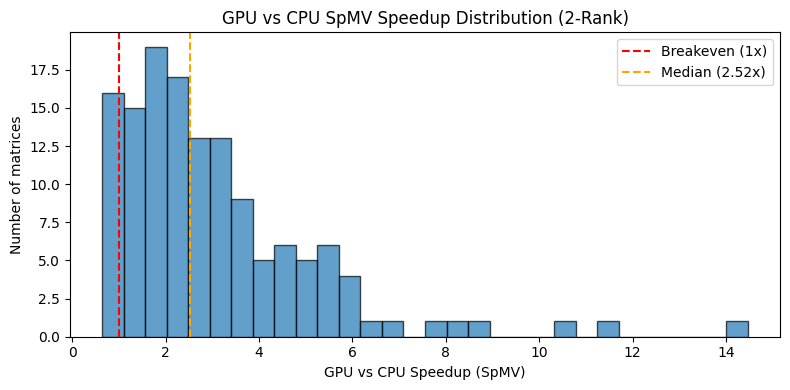

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cg2["speedup"], bins=30, edgecolor="black", alpha=0.7)
ax.axvline(1.0, color="red", linestyle="--", label="Breakeven (1x)")
ax.axvline(cg2["speedup"].median(), color="orange", linestyle="--", label=f"Median ({cg2['speedup'].median():.2f}x)")
ax.set_xlabel("GPU vs CPU Speedup (SpMV)")
ax.set_ylabel("Number of matrices")
ax.set_title("GPU vs CPU SpMV Speedup Distribution (2-Rank)")
ax.legend()
plt.tight_layout()

## 1.4 MPI+GPU vs GPU (SpMV, 2 Ranks)

Best partition configuration per matrix (minimizing SpMV time across all weight/imbalance combinations). Speedup = GPU time / MPI+GPU time; values > 1 mean MPI+GPU wins.

In [10]:
mg2 = df2_ok[df2_ok["solver_type"] == "mpi_gpu"].copy()

# Best (min spmv) partition per matrix
best_mg2 = mg2.loc[mg2.groupby("matrix")["spmv"].idxmin()][
    ["matrix", "spmv", "weight", "imbalance"]
].rename(columns={"spmv": "mg_spmv"})

mg2_cmp = gpu2.merge(best_mg2, on="matrix")
mg2_cmp["speedup"] = mg2_cmp["gpu_spmv"] / mg2_cmp["mg_spmv"]

print(f"Matrices compared: {len(mg2_cmp)}")
print(f"MPI+GPU faster (SpMV): {(mg2_cmp['speedup'] > 1).sum()}/{len(mg2_cmp)}")
print(f"Best case:  {mg2_cmp['speedup'].max():.2f}x")
print(f"Mean:       {mg2_cmp['speedup'].mean():.2f}x")
print(f"Median:     {mg2_cmp['speedup'].median():.2f}x")
print(f"Worst case: {mg2_cmp['speedup'].min():.2f}x")

print("\nTop 20 closest to beating GPU (SpMV):")
mg2_cmp.nlargest(20, "speedup")[
    ["matrix", "speedup", "gpu_spmv", "mg_spmv", "weight", "imbalance"]
]

Matrices compared: 136
MPI+GPU faster (SpMV): 0/136
Best case:  0.98x
Mean:       0.76x
Median:     0.76x
Worst case: 0.36x

Top 20 closest to beating GPU (SpMV):


,matrix,speedup,gpu_spmv,mg_spmv,weight,imbalance
76,laminar_duct3D,0.984245,0.464926,0.472368,75_25,50.0
102,raefsky3,0.948057,0.251402,0.265176,75_25,20.0
89,mixtank_new,0.941466,0.302736,0.321558,90_10,3.0
77,li,0.927555,0.242539,0.261482,75_25,20.0
115,sme3Db,0.927027,0.311711,0.336248,75_25,50.0
68,invextr1_new,0.923583,0.287045,0.310795,90_10,3.0
116,sme3Dc,0.919621,0.400552,0.435562,90_10,3.0
130,windtunnel_evap3d,0.917545,0.363547,0.396217,75_25,20.0
48,ex11,0.897818,0.218423,0.243282,90_10,5.0
95,ns3Da,0.886777,0.266668,0.300716,75_25,50.0


In [11]:
# Same analysis on everything_total
gpu2_t = df2_ok[df2_ok["solver_type"] == "gpu"][["matrix", "everything_total"]].rename(
    columns={"everything_total": "gpu_total"})
best_mg2_t = mg2.loc[mg2.groupby("matrix")["everything_total"].idxmin()][
    ["matrix", "everything_total"]
].rename(columns={"everything_total": "mg_total"})

mg2_total = gpu2_t.merge(best_mg2_t, on="matrix")
mg2_total["speedup"] = mg2_total["gpu_total"] / mg2_total["mg_total"]

wins_total = mg2_total[mg2_total["speedup"] > 1].sort_values("speedup", ascending=False)
print(f"MPI+GPU faster (everything_total): {len(wins_total)}/{len(mg2_total)}")
if len(wins_total) > 0:
    print("\nWinning matrices:")
    print(wins_total[["matrix", "speedup", "gpu_total", "mg_total"]].to_string(index=False))

MPI+GPU faster (everything_total): 2/136

Winning matrices:
    matrix  speedup  gpu_total  mg_total
  k3plates 1.105167   0.408030  0.369202
Zd_Jac6_db 1.035450   0.485538  0.468915


## 1.5 MPI (2-Rank CPU) vs Single CPU (SpMV)

Two MPI ranks, both CPU-only. Best partition per matrix. Speedup = CPU time / MPI time.

In [12]:
mpi2 = df2_ok[df2_ok["solver_type"] == "mpi"].copy()
best_mpi2 = mpi2.loc[mpi2.groupby("matrix")["spmv"].idxmin()][
    ["matrix", "spmv"]
].rename(columns={"spmv": "mpi_spmv"})

mc2 = cpu2.merge(best_mpi2, on="matrix")
mc2["speedup"] = mc2["cpu_spmv"] / mc2["mpi_spmv"]

print(f"Matrices compared: {len(mc2)}")
print(f"MPI faster than CPU: {(mc2['speedup'] > 1).sum()}/{len(mc2)}")
print(f"Mean speedup:   {mc2['speedup'].mean():.2f}x")
print(f"Median speedup: {mc2['speedup'].median():.2f}x")
print(f"Max speedup:    {mc2['speedup'].max():.2f}x")

print("\nTop 10 matrices:")
mc2.nlargest(10, "speedup")[["matrix", "speedup", "cpu_spmv", "mpi_spmv"]]

Matrices compared: 212
MPI faster than CPU: 212/212
Mean speedup:   1.68x
Median speedup: 1.68x
Max speedup:    2.21x

Top 10 matrices:


,matrix,speedup,cpu_spmv,mpi_spmv
161,poli3,2.213872,0.178686,0.080712
72,epb1,2.106267,0.141975,0.067406
163,poli_large,2.078516,0.125083,0.060179
73,epb2,2.043531,0.248571,0.121638
164,powersim,2.034829,0.127423,0.062621
5,ABACUS_shell_ud_M,2.023851,0.274588,0.135676
3,ABACUS_shell_ud,1.965831,0.281281,0.143085
50,bips07_1693,1.935610,0.119342,0.061656
146,mimo46x46_system,1.923319,0.117434,0.061058
201,viscoplastic2_C_7,1.916228,0.451517,0.235628


## 1.6 Convergence (1000 Iterations)

At 20 iterations, 78/213 (37%) appeared converged. At 1000 iterations, fewer converge because ill-conditioned matrices have time to diverge. This is expected behavior without preconditioning.

In [13]:
cpu2_ok = df2_ok[df2_ok["solver_type"] == "cpu"].copy()
cpu2_ok["residual"] = pd.to_numeric(cpu2_ok["relative_residual"], errors="coerce")

thresholds = [1e-10, 1e-6, 1e-3, 1e-1, 1.0]
print(f"Total CPU successes: {len(cpu2_ok)}")
print(f"NAN residual: {cpu2_ok['residual'].isna().sum()}\n")

print("Convergence by threshold:")
for t in thresholds:
    n = (cpu2_ok["residual"] < t).sum()
    print(f"  < {t:.0e}: {n:3d} ({100 * n / len(cpu2_ok):.1f}%)")

diverged = (cpu2_ok["residual"] >= 1.0).sum()
print(f"  >= 1  : {diverged:3d} ({100 * diverged / len(cpu2_ok):.1f}%) -- diverged")

Total CPU successes: 212
NAN residual: 8

Convergence by threshold:
  < 1e-10:   9 (4.2%)
  < 1e-06:  24 (11.3%)
  < 1e-03:  62 (29.2%)
  < 1e-01:  81 (38.2%)
  < 1e+00:  92 (43.4%)
  >= 1  : 112 (52.8%) -- diverged


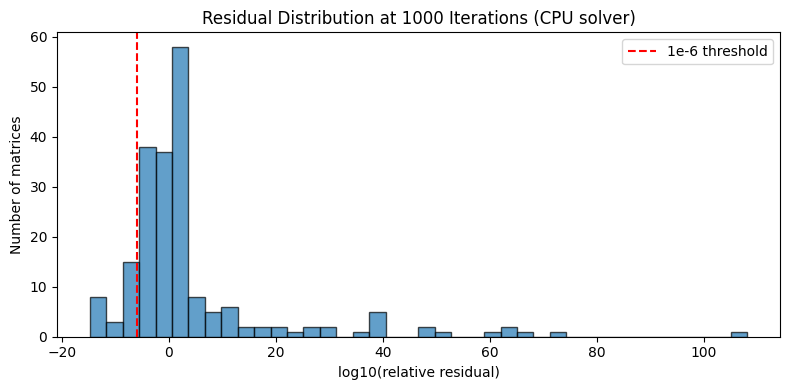

In [14]:
# Residual distribution histogram (log scale)
valid = cpu2_ok["residual"].dropna()
valid_pos = valid[valid > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(valid_pos), bins=40, edgecolor="black", alpha=0.7)
ax.axvline(-6, color="red", linestyle="--", label="1e-6 threshold")
ax.set_xlabel("log10(relative residual)")
ax.set_ylabel("Number of matrices")
ax.set_title("Residual Distribution at 1000 Iterations (CPU solver)")
ax.legend()
plt.tight_layout()

## 1.7 MPI+GPU Success Rate by Weight Profile

In [15]:
mg2_all = df2[df2["solver_type"] == "mpi_gpu"].copy()

weight_stats = []
for weight in sorted(mg2_all["weight"].dropna().unique()):
    total = len(mg2_all[mg2_all["weight"] == weight])
    ok = len(df2_ok[(df2_ok["solver_type"] == "mpi_gpu") & (df2_ok["weight"] == weight)])
    weight_stats.append({"weight": weight, "success": ok, "total": total, "rate": f"{100*ok/total:.0f}%"})

pd.DataFrame(weight_stats)

,weight,success,total,rate
0,50_50,3773,4260,89%
1,66_33,3784,4251,89%
2,75_25,3640,4153,88%
3,90_10,2606,3244,80%


# Part 2: 17-Rank Benchmark (16 CPU + 1 GPU)

**Date:** 2026-04-06  
**Setup:** 17 MPI ranks, rankfile `16cpu_1gpu.rankfile`, is_gpu `g17_17.txt`  
**Scope:** 322 matrices, 42 weight profiles, 3 imbalance ratios (1%, 3%, 10%), 1000 iterations  
**Pipeline:** `sample_mpi_gpu.py` -> per-matrix TSV files in `data/logs/`

## 2.1 Load 17-Rank Data

In [16]:
# Load all per-matrix TSV files from data/logs/
tsv_files = sorted(LOGS_17RANK.glob("benchmark_results_*.tsv"))
print(f"TSV files found: {len(tsv_files)}")

dfs_17 = [pd.read_csv(f, sep="\t") for f in tsv_files]
df17 = pd.concat(dfs_17, ignore_index=True)

# Parse weight and imbalance from partition_file column
# Format: "w{cpu_weight}-{gpu_weight}_17_i{imbalance}.part" or "cpu"/"gpu"
def parse_partition(pf):
    m = re.match(r"w(\d+)-(\d+)_(\d+)_i(\d+)\.part", str(pf))
    if m:
        return pd.Series({
            "weight_cpu": int(m.group(1)),
            "weight_gpu": int(m.group(2)),
            "n_ranks": int(m.group(3)),
            "imbalance": int(m.group(4)),
            "run_type": "mpi_gpu",
        })
    if pf == "cpu":
        return pd.Series({"weight_cpu": None, "weight_gpu": None, "n_ranks": 1, "imbalance": None, "run_type": "cpu"})
    if pf == "gpu":
        return pd.Series({"weight_cpu": None, "weight_gpu": None, "n_ranks": 1, "imbalance": None, "run_type": "gpu"})
    return pd.Series({"weight_cpu": None, "weight_gpu": None, "n_ranks": None, "imbalance": None, "run_type": "unknown"})

parsed = df17["partition_file"].apply(parse_partition)
df17 = pd.concat([df17, parsed], axis=1)

print(f"Total successful runs: {len(df17)}")
print(f"Unique matrices: {df17['matrix_name'].nunique()}")
print(f"\nRun type counts:")
print(df17["run_type"].value_counts().to_string())
df17.head(3)

TSV files found: 322
Total successful runs: 14500
Unique matrices: 322

Run type counts:
run_type
mpi_gpu    13968
cpu          322
gpu          210


,matrix_name,partition_file,mpi_procs,n_iters,spmv,file_read,relative_residual,everything_total,weight_cpu,weight_gpu,n_ranks,imbalance,run_type
0,2D_54019_highK,cpu,1,1000,1.003709,0.133618,0.0,1.138166,NaN,NaN,1,NaN,cpu
1,2D_54019_highK,gpu,1,1000,0.227644,0.129283,0.0,0.550548,NaN,NaN,1,NaN,gpu
2,2D_54019_highK,w100-100_17_i1.part,17,1000,0.389187,0.145139,0.0,0.534364,100.0,100.0,17,1.0,mpi_gpu


## 2.2 Test Results Overview

The TSV files only contain successful runs. Failures must be counted from the stderr log files in `data/logs/`.

In [17]:
# Count failures from stderr log files
# Naming: mpi_gpu_{matrix}_{weight}_{ranks}_i{imbalance}_stderr_failure.txt
failure_files = sorted(LOGS_17RANK.glob("mpi_gpu_*_stderr_failure.txt"))
gpu_failures = sorted(LOGS_17RANK.glob("gpu_*_stderr_failure.txt"))
cpu_failures = sorted(LOGS_17RANK.glob("cpu_*_stderr_failure.txt"))

print(f"Successful runs (from TSVs): {len(df17)}")
print(f"  CPU:     {len(df17[df17['run_type'] == 'cpu'])}")
print(f"  GPU:     {len(df17[df17['run_type'] == 'gpu'])}")
print(f"  MPI+GPU: {len(df17[df17['run_type'] == 'mpi_gpu'])}")
print(f"\nFailed runs (from stderr files):")
print(f"  CPU:     {len(cpu_failures)}")
print(f"  GPU:     {len(gpu_failures)}")
print(f"  MPI+GPU: {len(failure_files)}")
print(f"\nTotal: {len(df17) + len(failure_files) + len(gpu_failures) + len(cpu_failures)}")

Successful runs (from TSVs): 14500
  CPU:     322
  GPU:     210
  MPI+GPU: 13968

Failed runs (from stderr files):
  CPU:     0
  GPU:     0
  MPI+GPU: 22801

Total: 37301


In [18]:
# Categorize failure types by scanning stderr content
# This takes ~30s due to 22,801 files
empty_csc_count = 0
vec_zero_count = 0

for f in failure_files:
    content = f.read_text()
    if "empty matrix to CSC" in content:
        empty_csc_count += 1
    elif "Vector of size 0" in content or "vector of size 0" in content:
        vec_zero_count += 1

print("MPI+GPU failure breakdown:")
print(f"  'Tried to convert empty matrix to CSC': {empty_csc_count}")
print(f"  'Attempted to create a vector of size 0': {vec_zero_count}")
print(f"  Other: {len(failure_files) - empty_csc_count - vec_zero_count}")
print(f"\nBoth errors are caused by partitions that assign zero rows to a rank.")
print(f"With 17 partitions this is much more likely than with 2.")

MPI+GPU failure breakdown:
  'Tried to convert empty matrix to CSC': 21743
  'Attempted to create a vector of size 0': 1058
  Other: 0

Both errors are caused by partitions that assign zero rows to a rank.
With 17 partitions this is much more likely than with 2.


## 2.3 MPI+GPU vs GPU (SpMV, 17 Ranks)

Same analysis as Section 1.4 but with 16 CPU + 1 GPU ranks.

In [19]:
gpu17 = df17[df17["run_type"] == "gpu"][["matrix_name", "spmv", "everything_total"]].rename(
    columns={"spmv": "gpu_spmv", "everything_total": "gpu_total"})
mg17 = df17[df17["run_type"] == "mpi_gpu"].copy()

# Merge all mpi_gpu runs with their gpu baseline
mg17_cmp = mg17.merge(gpu17, on="matrix_name")
mg17_cmp["spmv_ratio"] = mg17_cmp["spmv"] / mg17_cmp["gpu_spmv"]  # < 1 means MPI+GPU wins
mg17_cmp["speedup"] = mg17_cmp["gpu_spmv"] / mg17_cmp["spmv"]     # > 1 means MPI+GPU wins

print(f"Total configs compared: {len(mg17_cmp)}")
print(f"MPI+GPU faster (SpMV): {(mg17_cmp['speedup'] > 1).sum()}/{len(mg17_cmp)}")
print(f"Best ratio:  {mg17_cmp['spmv_ratio'].min():.3f}x (closest to winning)")
print(f"Mean ratio:  {mg17_cmp['spmv_ratio'].mean():.3f}x")
print(f"Median ratio:{mg17_cmp['spmv_ratio'].median():.3f}x")

print("\nTop 20 closest to beating GPU (SpMV):")
mg17_cmp.nsmallest(20, "spmv_ratio")[
    ["matrix_name", "spmv_ratio", "gpu_spmv", "spmv", "partition_file"]
]

Total configs compared: 10404
MPI+GPU faster (SpMV): 0/10404
Best ratio:  1.193x (closest to winning)
Mean ratio:  3.758x
Median ratio:3.277x

Top 20 closest to beating GPU (SpMV):


,matrix_name,spmv_ratio,gpu_spmv,spmv,partition_file
14,2D_54019_highK,1.193104,0.227644,0.271603,w150-100_17_i3.part
13,2D_54019_highK,1.196676,0.227644,0.272416,w150-100_17_i10.part
1,2D_54019_highK,1.197664,0.227644,0.272641,w100-100_17_i10.part
25,2D_54019_highK,1.199215,0.227644,0.272994,w200-100_17_i3.part
51,2D_54019_highK,1.204745,0.227644,0.274253,w300-100_17_i1.part
42,2D_54019_highK,1.205031,0.227644,0.274318,w250-100_17_i1.part
35,2D_54019_highK,1.206006,0.227644,0.274540,w219-100_17_i3.part
53,2D_54019_highK,1.208791,0.227644,0.275174,w300-100_17_i3.part
23,2D_54019_highK,1.210091,0.227644,0.275470,w200-100_17_i1.part
8968,std1_Jac2_db,1.210927,0.223731,0.270922,w200-100_17_i10.part


## 2.4 MPI+GPU vs GPU (everything_total, 17 Ranks)

`everything_total` includes file I/O, cuSPARSE descriptor setup, and SpMV. Some matrices show MPI+GPU wins here due to GPU setup overhead being amortized differently, not due to SpMV improvement.

In [20]:
mg17_cmp["total_ratio"] = mg17_cmp["everything_total"] / mg17_cmp["gpu_total"]

wins_17t = mg17_cmp[mg17_cmp["total_ratio"] < 1].sort_values("total_ratio")
print(f"MPI+GPU faster (everything_total): {len(wins_17t)}/{len(mg17_cmp)}")
print(f"Unique matrices: {wins_17t['matrix_name'].nunique()}")

if len(wins_17t) > 0:
    print("\nTop 20 wins:")
    print(wins_17t.head(20)[
        ["matrix_name", "total_ratio", "gpu_total", "everything_total", "partition_file"]
    ].to_string(index=False))

MPI+GPU faster (everything_total): 41/10404
Unique matrices: 13

Top 20 wins:
     matrix_name  total_ratio  gpu_total  everything_total       partition_file
         rajat04     0.905058   0.633195          0.573078  w300-600_17_i1.part
Hamrle_test_mc64     0.908002   0.597969          0.542957 w150-100_17_i10.part
    std1_Jac2_db     0.931043   0.788269          0.733912  w200-100_17_i3.part
     bips07_1998     0.938836   0.643092          0.603758  w250-100_17_i3.part
         rajat04     0.941271   0.633195          0.596008  w219-600_17_i1.part
         rajat04     0.947530   0.633195          0.599971  w100-600_17_i1.part
  adder_trans_02     0.948707   0.682979          0.647947  w300-600_17_i1.part
         rajat04     0.953695   0.633195          0.603875  w219-600_17_i3.part
         rajat12     0.957190   0.628144          0.601253  w250-400_17_i3.part
  adder_trans_02     0.961167   0.682979          0.656457  w100-600_17_i1.part
         rajat04     0.965241   0.633195  

# Part 3: Cross-Rank Comparison

Comparing the 2-rank and 17-rank MPI+GPU results to understand how rank count affects performance.

## 3.1 SpMV Ratio Comparison

In [21]:
# Build per-matrix best SpMV ratio for each rank config
# 2-rank: ratio = mpi_gpu_spmv / gpu_spmv (< 1 means MPI+GPU wins)
mg2_all_cmp = mg2.merge(gpu2, on="matrix")
mg2_all_cmp["spmv_ratio"] = mg2_all_cmp["spmv"] / mg2_all_cmp["gpu_spmv"]
best_2rank = mg2_all_cmp.groupby("matrix")["spmv_ratio"].min().reset_index()
best_2rank.columns = ["matrix", "best_ratio_2rank"]

# 17-rank
best_17rank = mg17_cmp.groupby("matrix_name")["spmv_ratio"].min().reset_index()
best_17rank.columns = ["matrix", "best_ratio_17rank"]

cross = best_2rank.merge(best_17rank, on="matrix", how="inner")

print(f"Matrices in both benchmarks: {len(cross)}")
print(f"\n{'Metric':<30s} {'2-rank':>10s} {'17-rank':>10s}")
print("-" * 52)
print(f"{'Best ratio (closest to 1)':<30s} {cross['best_ratio_2rank'].min():>10.3f} {cross['best_ratio_17rank'].min():>10.3f}")
print(f"{'Mean best ratio':<30s} {cross['best_ratio_2rank'].mean():>10.3f} {cross['best_ratio_17rank'].mean():>10.3f}")
print(f"{'Median best ratio':<30s} {cross['best_ratio_2rank'].median():>10.3f} {cross['best_ratio_17rank'].median():>10.3f}")
print(f"{'SpMV wins (ratio < 1)':<30s} {(cross['best_ratio_2rank'] < 1).sum():>10d} {(cross['best_ratio_17rank'] < 1).sum():>10d}")

Matrices in both benchmarks: 129

Metric                             2-rank    17-rank
----------------------------------------------------
Best ratio (closest to 1)           1.016      1.193
Mean best ratio                     1.325      1.941
Median best ratio                   1.316      1.878
SpMV wins (ratio < 1)                   0          0


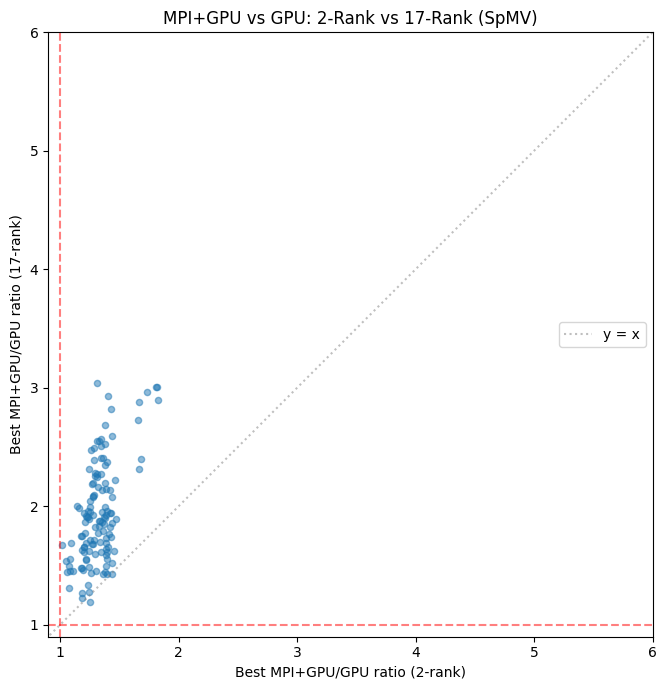

In [22]:
# Scatter: 2-rank ratio vs 17-rank ratio per matrix
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cross["best_ratio_2rank"], cross["best_ratio_17rank"], alpha=0.5, s=20)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.5)
ax.axvline(1.0, color="red", linestyle="--", alpha=0.5)
ax.plot([0, 10], [0, 10], color="gray", linestyle=":", alpha=0.5, label="y = x")
ax.set_xlabel("Best MPI+GPU/GPU ratio (2-rank)")
ax.set_ylabel("Best MPI+GPU/GPU ratio (17-rank)")
ax.set_title("MPI+GPU vs GPU: 2-Rank vs 17-Rank (SpMV)")
ax.set_xlim(0.9, 6)
ax.set_ylim(0.9, 6)
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()

## 3.2 Discussion

Neither 2-rank (1 CPU + 1 GPU) nor 17-rank (16 CPU + 1 GPU) achieves an MPI+GPU SpMV win over single GPU.

**2-rank** has lower overhead (fewer ranks = less communication) but insufficient CPU compute to offset it. Best ratio: ~1.016x (1.6% slower).

**17-rank** has more CPU compute but communication overhead scales with rank count and dominates. Best ratio: ~1.193x (19.3% slower) — significantly worse than 2-rank.

Points above the y=x diagonal in the scatter plot are matrices where 17-rank is worse than 2-rank, which is the majority. The MPI communication cost grows faster than the benefit of additional CPU ranks.

### Possible paths forward

1. **Computation-communication overlap:** Async SpMV (compute local part while exchanging shared columns)
2. **Larger matrices:** Current matrices may be too small for 17-rank parallelism to pay off
3. **Fix empty-partition crashes:** 64% of 17-rank configs fail, excluding potentially favorable configurations

## 3.3 17-Rank Failure Analysis by Weight

Parse failure filenames to determine which weight configurations cause the most empty-partition crashes.

In [23]:
# Parse weight from failure filenames
# Format: mpi_gpu_{matrix}_{weight_pattern}_stderr_failure.txt
# Weight pattern: w{cpu}-{gpu}_{ranks}_i{imbalance}
fail_pattern = re.compile(r"mpi_gpu_.*_(w\d+-\d+)_(\d+)_i(\d+)_stderr_failure\.txt")

fail_records = []
for f in failure_files:
    m = fail_pattern.search(f.name)
    if m:
        fail_records.append({
            "weight": m.group(1),
            "n_ranks": int(m.group(2)),
            "imbalance": int(m.group(3)),
        })

fail_df = pd.DataFrame(fail_records)
print(f"Parsed {len(fail_df)} of {len(failure_files)} failure filenames")

# Also build success counts from df17 for the same weight categories
mg17_success = df17[df17["run_type"] == "mpi_gpu"].copy()
mg17_success["weight"] = mg17_success.apply(
    lambda r: f"w{int(r['weight_cpu'])}-{int(r['weight_gpu'])}" if pd.notna(r["weight_cpu"]) else None,
    axis=1
)

Parsed 22801 of 22801 failure filenames


In [24]:
# Failure rate by GPU weight (aggregated across CPU weights and imbalance)
fail_by_weight = fail_df.groupby("weight").size().reset_index(name="failures")
success_by_weight = mg17_success.groupby("weight").size().reset_index(name="successes")

rate_df = fail_by_weight.merge(success_by_weight, on="weight", how="outer").fillna(0)
rate_df["total"] = rate_df["failures"] + rate_df["successes"]
rate_df["fail_rate"] = rate_df["failures"] / rate_df["total"]

# Extract GPU weight for sorting
rate_df["gpu_weight"] = rate_df["weight"].str.extract(r"-(\d+)").astype(int)
rate_df = rate_df.sort_values("gpu_weight")

print("Failure rate by weight profile:")
print(rate_df[["weight", "successes", "failures", "total", "fail_rate"]].to_string(index=False))

Failure rate by weight profile:
   weight  successes  failures  total  fail_rate
 w100-100      765.0        13  778.0   0.016710
 w150-100      774.0        14  788.0   0.017766
 w200-100      764.0        32  796.0   0.040201
 w219-100      783.0        30  813.0   0.036900
 w250-100      772.0        40  812.0   0.049261
 w300-100      751.0        47  798.0   0.058897
 w150-400      482.0       352  834.0   0.422062
 w219-400      465.0       357  822.0   0.434307
 w200-400      463.0       359  822.0   0.436740
 w300-400      475.0       362  837.0   0.432497
 w250-400      476.0       363  839.0   0.432658
 w100-400      474.0       320  794.0   0.403023
 w100-600      477.0       363  840.0   0.432143
 w150-600      486.0       366  852.0   0.429577
 w219-600      461.0       362  823.0   0.439854
 w200-600      456.0       365  821.0   0.444580
 w250-600      246.0       645  891.0   0.723906
 w300-600      229.0       662  891.0   0.742985
 w250-800      233.0       666  899.0

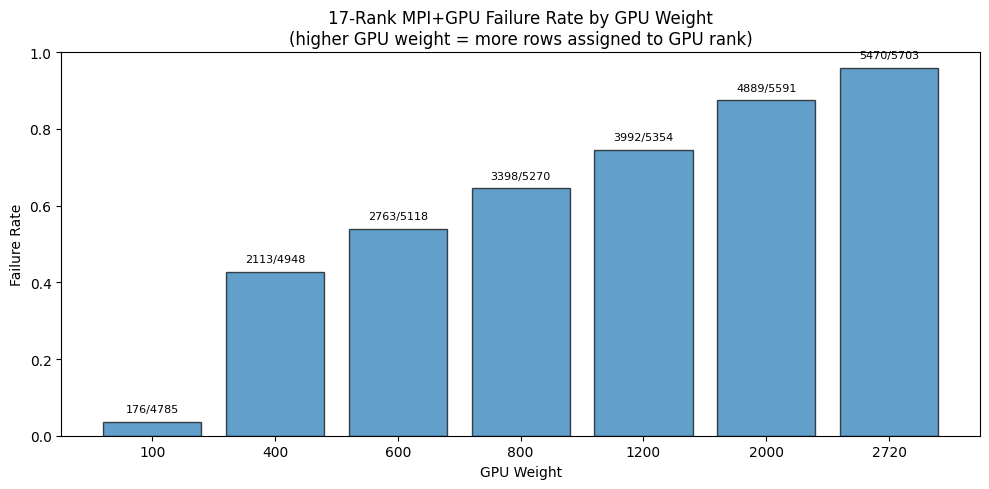

In [25]:
# Visualize: failure rate by GPU weight
fig, ax = plt.subplots(figsize=(10, 5))

# Group by GPU weight for cleaner visualization
gpu_group = rate_df.groupby("gpu_weight").agg(
    failures=("failures", "sum"),
    successes=("successes", "sum"),
    total=("total", "sum"),
).reset_index()
gpu_group["fail_rate"] = gpu_group["failures"] / gpu_group["total"]

bars = ax.bar(gpu_group["gpu_weight"].astype(str), gpu_group["fail_rate"], 
              edgecolor="black", alpha=0.7)
ax.set_xlabel("GPU Weight")
ax.set_ylabel("Failure Rate")
ax.set_title("17-Rank MPI+GPU Failure Rate by GPU Weight\n(higher GPU weight = more rows assigned to GPU rank)")
ax.set_ylim(0, 1)

# Add count labels on bars
for bar, row in zip(bars, gpu_group.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{int(row.failures)}/{int(row.total)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

In [26]:
# Failure rate by imbalance
imbal_group = fail_df.groupby("imbalance").size().reset_index(name="failures")
imbal_success = mg17_success.groupby("imbalance").size().reset_index(name="successes")
# Ensure imbalance is same type for merge
imbal_success["imbalance"] = imbal_success["imbalance"].astype(int)

imbal_rate = imbal_group.merge(imbal_success, on="imbalance", how="outer").fillna(0)
imbal_rate["total"] = imbal_rate["failures"] + imbal_rate["successes"]
imbal_rate["fail_rate"] = imbal_rate["failures"] / imbal_rate["total"]
imbal_rate = imbal_rate.sort_values("imbalance")

print("Failure rate by imbalance:")
print(imbal_rate[["imbalance", "successes", "failures", "total", "fail_rate"]].to_string(index=False))

Failure rate by imbalance:
 imbalance  successes  failures  total  fail_rate
         1       8008      3286  11294   0.290951
         3       4393      7978  12371   0.644895
        10       1567     11537  13104   0.880418
